In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\manh\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
import warnings

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message="DataFrameGroupBy.apply operated on the grouping columns.*"
)

In [3]:
df_first = pd.read_csv("./data/vn30_filtered.csv")
df_first

,symbol,time,close,volume,vnindex
0,ACB,2017-01-03,3.33,1609757,672.01
1,ACB,2017-01-04,3.35,739000,674.70
2,ACB,2017-01-05,3.35,471881,675.81
3,ACB,2017-01-06,3.53,1409824,679.80
4,ACB,2017-01-09,3.65,970791,682.57
...,...,...,...,...,...
53045,VRE,2025-12-25,32.25,17089700,1742.85
53046,VRE,2025-12-26,32.00,20927400,1729.80
53047,VRE,2025-12-29,33.20,7573400,1754.84
53048,VRE,2025-12-30,32.80,8839700,1766.90


# Add feature

In [4]:
def _get_prefix(col_name):
    if col_name.startswith("close"):
        return "stock"
    elif col_name.startswith("vnindex"):
        return "market"
    elif col_name.startswith("stock_lret"):
        return "stock_lret"
    elif col_name.startswith("market_lret"):
        return "market_lret"
    elif col_name.startswith("excess_lret"):
        return "excess_lret"
    elif col_name.startswith("idio_lret"):
        return col_name

In [5]:
def compute_log_return(
    df=None,
    computed_cols=["close", "vnindex"],
    shifts=1,
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    if isinstance(shifts, int):
        shifts = [shifts]

    for computed_col in computed_cols:
        df[computed_col] = df[computed_col].replace(0, np.nan)
        prefix = _get_prefix(computed_col)

        for shift in shifts:
            if shift == 1:
                col_name = f"{prefix}_lret"
            else:
                col_name = f"{prefix}_lret_{shift}"

            df[col_name] = df.groupby(group_col)[computed_col].transform(lambda x: np.log(x / x.shift(shift)))

    return df

In [6]:
def compute_momentum(
    df=None,
    computed_cols=["stock_lret", "market_lret", "excess_lret"],
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        prefix = _get_prefix(computed_col)
        
        for window in windows:
            col_name = f"{prefix}_mom_{window}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: x.rolling(window).sum()
                )
            )

    return df

In [7]:
def compute_volatility(
    df=None,
    computed_cols=["stock_lret", "market_lret", "excess_lret"],
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        prefix = _get_prefix(computed_col)

        for window in windows:
            col_name = f"{prefix}_vol_{window}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: x.rolling(window).std()
                )
            )

    return df

In [8]:
def compute_beta(
    df=None,
    stock_lret_col="stock_lret",
    market_lret_col="market_lret",
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for window in windows:
        beta_col = f"beta_{window}"

        df[beta_col] = (
            df.groupby(group_col).apply(
                lambda x: x[stock_lret_col].rolling(window).cov(x[market_lret_col]) / x[market_lret_col].rolling(window).var()
            ).reset_index(level=0, drop=True)
        )

    return df

In [9]:
def compute_corr(
    df=None,
    stock_lret_col="stock_lret",
    market_lret_col="market_lret",
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time",
):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for window in windows:
        corr_col = f"corr_{window}"

        df[corr_col] = df.groupby(group_col).apply(
            lambda x: x[stock_lret_col].rolling(window).corr(x[market_lret_col])
        ).reset_index(level=0, drop=True)

    return df

In [10]:
def compute_idio_lret(
    df=None,
    stock_lret_col="stock_lret",
    market_lret_col="market_lret",
    beta="beta",
    windows=[10, 20, 60]
):
    df = df.copy()

    for window in windows:
        beta_col = f"{beta}_{window}"
        idio_lret_col = f"idio_lret_with_beta_{window}"

        if beta_col not in df.columns:
            raise ValueError(f"Column '{beta_col}' does not exist.")

        df[idio_lret_col] = df[stock_lret_col] - df[beta_col] * df[market_lret_col]

    return df

In [11]:
def compute_pairwise_feature(
    df=None,
    left_prefix="stock",
    right_prefix="market",
    windows=[10, 20, 60],
    operation=None,
    output_prefix=None,
    group_col="symbol",
    time_col="time"
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    valid_operations = ["subtract", "divide"]
    if operation not in valid_operations:
        raise ValueError(f"operation must be one of {valid_operations}")

    for window in windows:
        left_col = f"{left_prefix}_{window}"
        right_col = f"{right_prefix}_{window}"

        if left_col not in df.columns:
            raise ValueError(f"Column '{left_col}' does not exist in dataframe.")
        if right_col not in df.columns:
            raise ValueError(f"Column '{right_col}' does not exist in dataframe.")

        output_col = f"{output_prefix}_{window}"

        if operation == "subtract":
            df[output_col] = df[left_col] - df[right_col]

        elif operation == "divide":
            df[output_col] = df[left_col] / df[right_col]

    return df

In [12]:

df = compute_log_return(df_first)
df["excess_lret"] = df["stock_lret"] - df["market_lret"]
df = compute_momentum(df)
df = compute_volatility(df)

df = compute_corr(df)
df = compute_beta(df)
df = compute_idio_lret(df)
idio_lret_cols = [f"idio_lret_with_beta_{i}" for i in [10, 20, 60]]
df = compute_momentum(df, computed_cols=idio_lret_cols)
df = compute_volatility(df, computed_cols=idio_lret_cols)

# df = compute_pairwise_feature(df, left_prefix="stock_mom", right_prefix="market_mom", operation="subtract", output_prefix="excess_mom")
# df = compute_pairwise_feature(df, left_prefix="stock_vol", right_prefix="market_vol", operation="divide", output_prefix="relative_vol")
# df = compute_pairwise_feature(df, left_prefix="stock_mom", right_prefix="stock_vol", operation="divide", output_prefix="sharpe_like")
# df = compute_pairwise_feature(df, left_prefix="idio_mom", right_prefix="idio_vol", operation="divide", output_prefix="idio_sharpe_like")

pd.set_option('display.max_columns', None)
df.tail(10)

,symbol,time,close,volume,vnindex,stock_lret,market_lret,excess_lret,stock_lret_mom_10,stock_lret_mom_20,stock_lret_mom_60,market_lret_mom_10,market_lret_mom_20,market_lret_mom_60,excess_lret_mom_10,excess_lret_mom_20,excess_lret_mom_60,stock_lret_vol_10,stock_lret_vol_20,stock_lret_vol_60,market_lret_vol_10,market_lret_vol_20,market_lret_vol_60,excess_lret_vol_10,excess_lret_vol_20,excess_lret_vol_60,corr_10,corr_20,corr_60,beta_10,beta_20,beta_60,idio_lret_with_beta_10,idio_lret_with_beta_20,idio_lret_with_beta_60,idio_lret_with_beta_10_mom_10,idio_lret_with_beta_10_mom_20,idio_lret_with_beta_10_mom_60,idio_lret_with_beta_20_mom_10,idio_lret_with_beta_20_mom_20,idio_lret_with_beta_20_mom_60,idio_lret_with_beta_60_mom_10,idio_lret_with_beta_60_mom_20,idio_lret_with_beta_60_mom_60,idio_lret_with_beta_10_vol_10,idio_lret_with_beta_10_vol_20,idio_lret_with_beta_10_vol_60,idio_lret_with_beta_20_vol_10,idio_lret_with_beta_20_vol_20,idio_lret_with_beta_20_vol_60,idio_lret_with_beta_60_vol_10,idio_lret_with_beta_60_vol_20,idio_lret_with_beta_60_vol_60
53040,VRE,2025-12-18,30.35,6326300,1676.98,0.021649,0.001982,0.019668,-0.125260,-0.052939,0.031802,-0.035303,0.012596,0.006515,-0.089957,-0.065535,0.025287,0.038849,0.033711,0.037774,0.013856,0.010992,0.013892,0.030702,0.027452,0.028864,0.704642,0.679582,0.749617,1.975588,2.084167,2.038340,0.017734,0.017519,0.017610,-0.052447,-0.116243,-0.023361,-0.039218,-0.069457,0.019330,-0.052150,-0.072041,0.025945,0.026926,0.024276,0.024972,0.027483,0.024321,0.024558,0.027510,0.024874,0.026963
53041,VRE,2025-12-19,31.70,10546100,1704.31,0.043520,0.016166,0.027354,-0.064144,-0.015650,0.075322,-0.021483,0.029402,0.025921,-0.042661,-0.045051,0.049401,0.042590,0.035225,0.038180,0.015137,0.011520,0.014038,0.032423,0.028222,0.029071,0.769177,0.711019,0.755282,2.164099,2.174174,2.054214,0.008536,0.008373,0.010312,-0.019044,-0.115732,-0.019314,-0.006591,-0.068775,0.025931,-0.019576,-0.069101,0.033281,0.026286,0.024292,0.024990,0.026727,0.024338,0.024579,0.027194,0.024951,0.026991
53042,VRE,2025-12-22,33.00,9656000,1751.03,0.040191,0.027044,0.013147,0.001516,-0.043001,0.095310,-0.001546,0.048591,0.049491,0.003063,-0.091592,0.045820,0.044350,0.032886,0.038434,0.017604,0.012807,0.014448,0.031187,0.024522,0.029042,0.835242,0.764768,0.758598,2.104282,1.963842,2.017993,-0.016717,-0.012919,-0.014383,0.003283,-0.178728,-0.049696,0.024136,-0.131351,-0.005167,0.005635,-0.136705,0.001880,0.023591,0.021054,0.025010,0.022699,0.020938,0.024526,0.024335,0.021160,0.026971
53043,VRE,2025-12-23,34.25,14877500,1772.15,0.037179,0.011989,0.025190,0.067951,0.025131,0.064831,0.014196,0.065159,0.064352,0.053754,-0.040028,0.000478,0.044432,0.033272,0.037741,0.017947,0.012865,0.014511,0.030641,0.024819,0.027757,0.851119,0.766928,0.789273,2.107151,1.983434,2.052820,0.011916,0.013399,0.012567,0.037450,-0.148803,-0.110147,0.057225,-0.097958,-0.060875,0.039959,-0.101585,-0.055708,0.022401,0.021435,0.023161,0.021499,0.021141,0.022860,0.023233,0.021244,0.025413
53044,VRE,2025-12-24,34.65,9103700,1782.82,0.011611,0.006003,0.005608,0.144100,0.023359,0.044255,0.036465,0.059188,0.068341,0.107635,-0.035830,-0.024086,0.036701,0.033240,0.037547,0.016857,0.012721,0.014524,0.024225,0.024867,0.027485,0.843953,0.766690,0.793368,1.837437,2.003424,2.050929,0.000581,-0.000415,-0.000700,0.061604,-0.127131,-0.138467,0.077145,-0.083305,-0.092386,0.070475,-0.093845,-0.086856,0.020335,0.021256,0.022810,0.019660,0.021024,0.022469,0.019852,0.021251,0.025077
53045,VRE,2025-12-25,32.25,17089700,1742.85,-0.071780,-0.022675,-0.049105,0.089128,-0.042495,0.015625,0.025541,0.034160,0.053105,0.063587,-0.076655,-0.037480,0.045061,0.037026,0.038289,0.018261,0.013955,0.014807,0.030590,0.027011,0.027828,0.867837,0.809082,0.803287,2.141459,2.146741,2.077131,-0.023223,-0.023103,-0.024681,0.032371,-0.138088,-0.134392,0.043372,-0.095003,-0.077680,0.038609,-0.108291,-0.075135,0.022360,0.021555,0.022740,0.021873,0.021395,0.022144,0.022241,0.021690,0.024845
53046,VRE,2025-12-

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53050 entries, 0 to 53049
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   symbol                         53050 non-null  object        
 1   time                           53050 non-null  datetime64[ns]
 2   close                          53050 non-null  float64       
 3   volume                         53050 non-null  int64         
 4   vnindex                        53050 non-null  float64       
 5   stock_lret                     53026 non-null  float64       
 6   market_lret                    53026 non-null  float64       
 7   excess_lret                    53026 non-null  float64       
 8   stock_lret_mom_10              52810 non-null  float64       
 9   stock_lret_mom_20              52570 non-null  float64       
 10  stock_lret_mom_60              51610 non-null  float64       
 11  market_lret_mom

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
time,53050,2021-07-29 02:04:42.028274944,2017-01-03 00:00:00,2019-05-20 00:00:00,2021-07-30 00:00:00,2023-10-17 00:00:00,2025-12-31 00:00:00,NaN
close,53050.0,37.428931,1.39,12.57,27.5,57.31,219.1,31.142643
volume,53050.0,5725899.447144,0.0,815846.5,2207239.0,6356197.75,249760712.0,10117486.481178
vnindex,53050.0,1120.909543,659.21,958.59,1099.49,1269.93,1784.49,233.814546
stock_lret,53026.0,0.000656,-0.164622,-0.008925,0.0,0.009903,1.304007,0.021763
market_lret,53026.0,0.000429,-0.069639,-0.004084,0.001419,0.006365,0.280823,0.012093
excess_lret,53026.0,0.000227,-0.114685,-0.008633,-0.001167,0.007558,1.023184,0.017118
stock_lret_mom_10,52810.0,0.006476,-0.432595,-0.028722,0.004622,0.042255,1.371445,0.071065
stock_lret_mom_20,52570.0,0.01284,-0.591249,-0.038376,0.00939,0.064676,1.386581,0.101481
stock_lret_mom_60,51610.0,0.038372,-0.872745,-0.066983,0.024791,0.13374,1.386581,0.183261


# Add label

In [15]:
def add_target(df, horizon=1):
    df = df.copy()
    df["target"] = df.groupby("symbol")["stock_lret"].shift(-horizon)
    df['target_time'] = df.groupby('symbol')['time'].shift(-horizon)
    df = df.dropna(subset=["target"])
    return df

In [16]:
df_final = add_target(df)
df_final = df_final.drop(["close", "volume", "vnindex"], axis=1, inplace=False)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53026 entries, 0 to 53048
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   symbol                         53026 non-null  object        
 1   time                           53026 non-null  datetime64[ns]
 2   stock_lret                     53002 non-null  float64       
 3   market_lret                    53002 non-null  float64       
 4   excess_lret                    53002 non-null  float64       
 5   stock_lret_mom_10              52786 non-null  float64       
 6   stock_lret_mom_20              52546 non-null  float64       
 7   stock_lret_mom_60              51586 non-null  float64       
 8   market_lret_mom_10             52786 non-null  float64       
 9   market_lret_mom_20             52546 non-null  float64       
 10  market_lret_mom_60             51586 non-null  float64       
 11  excess_lret_mom_10  

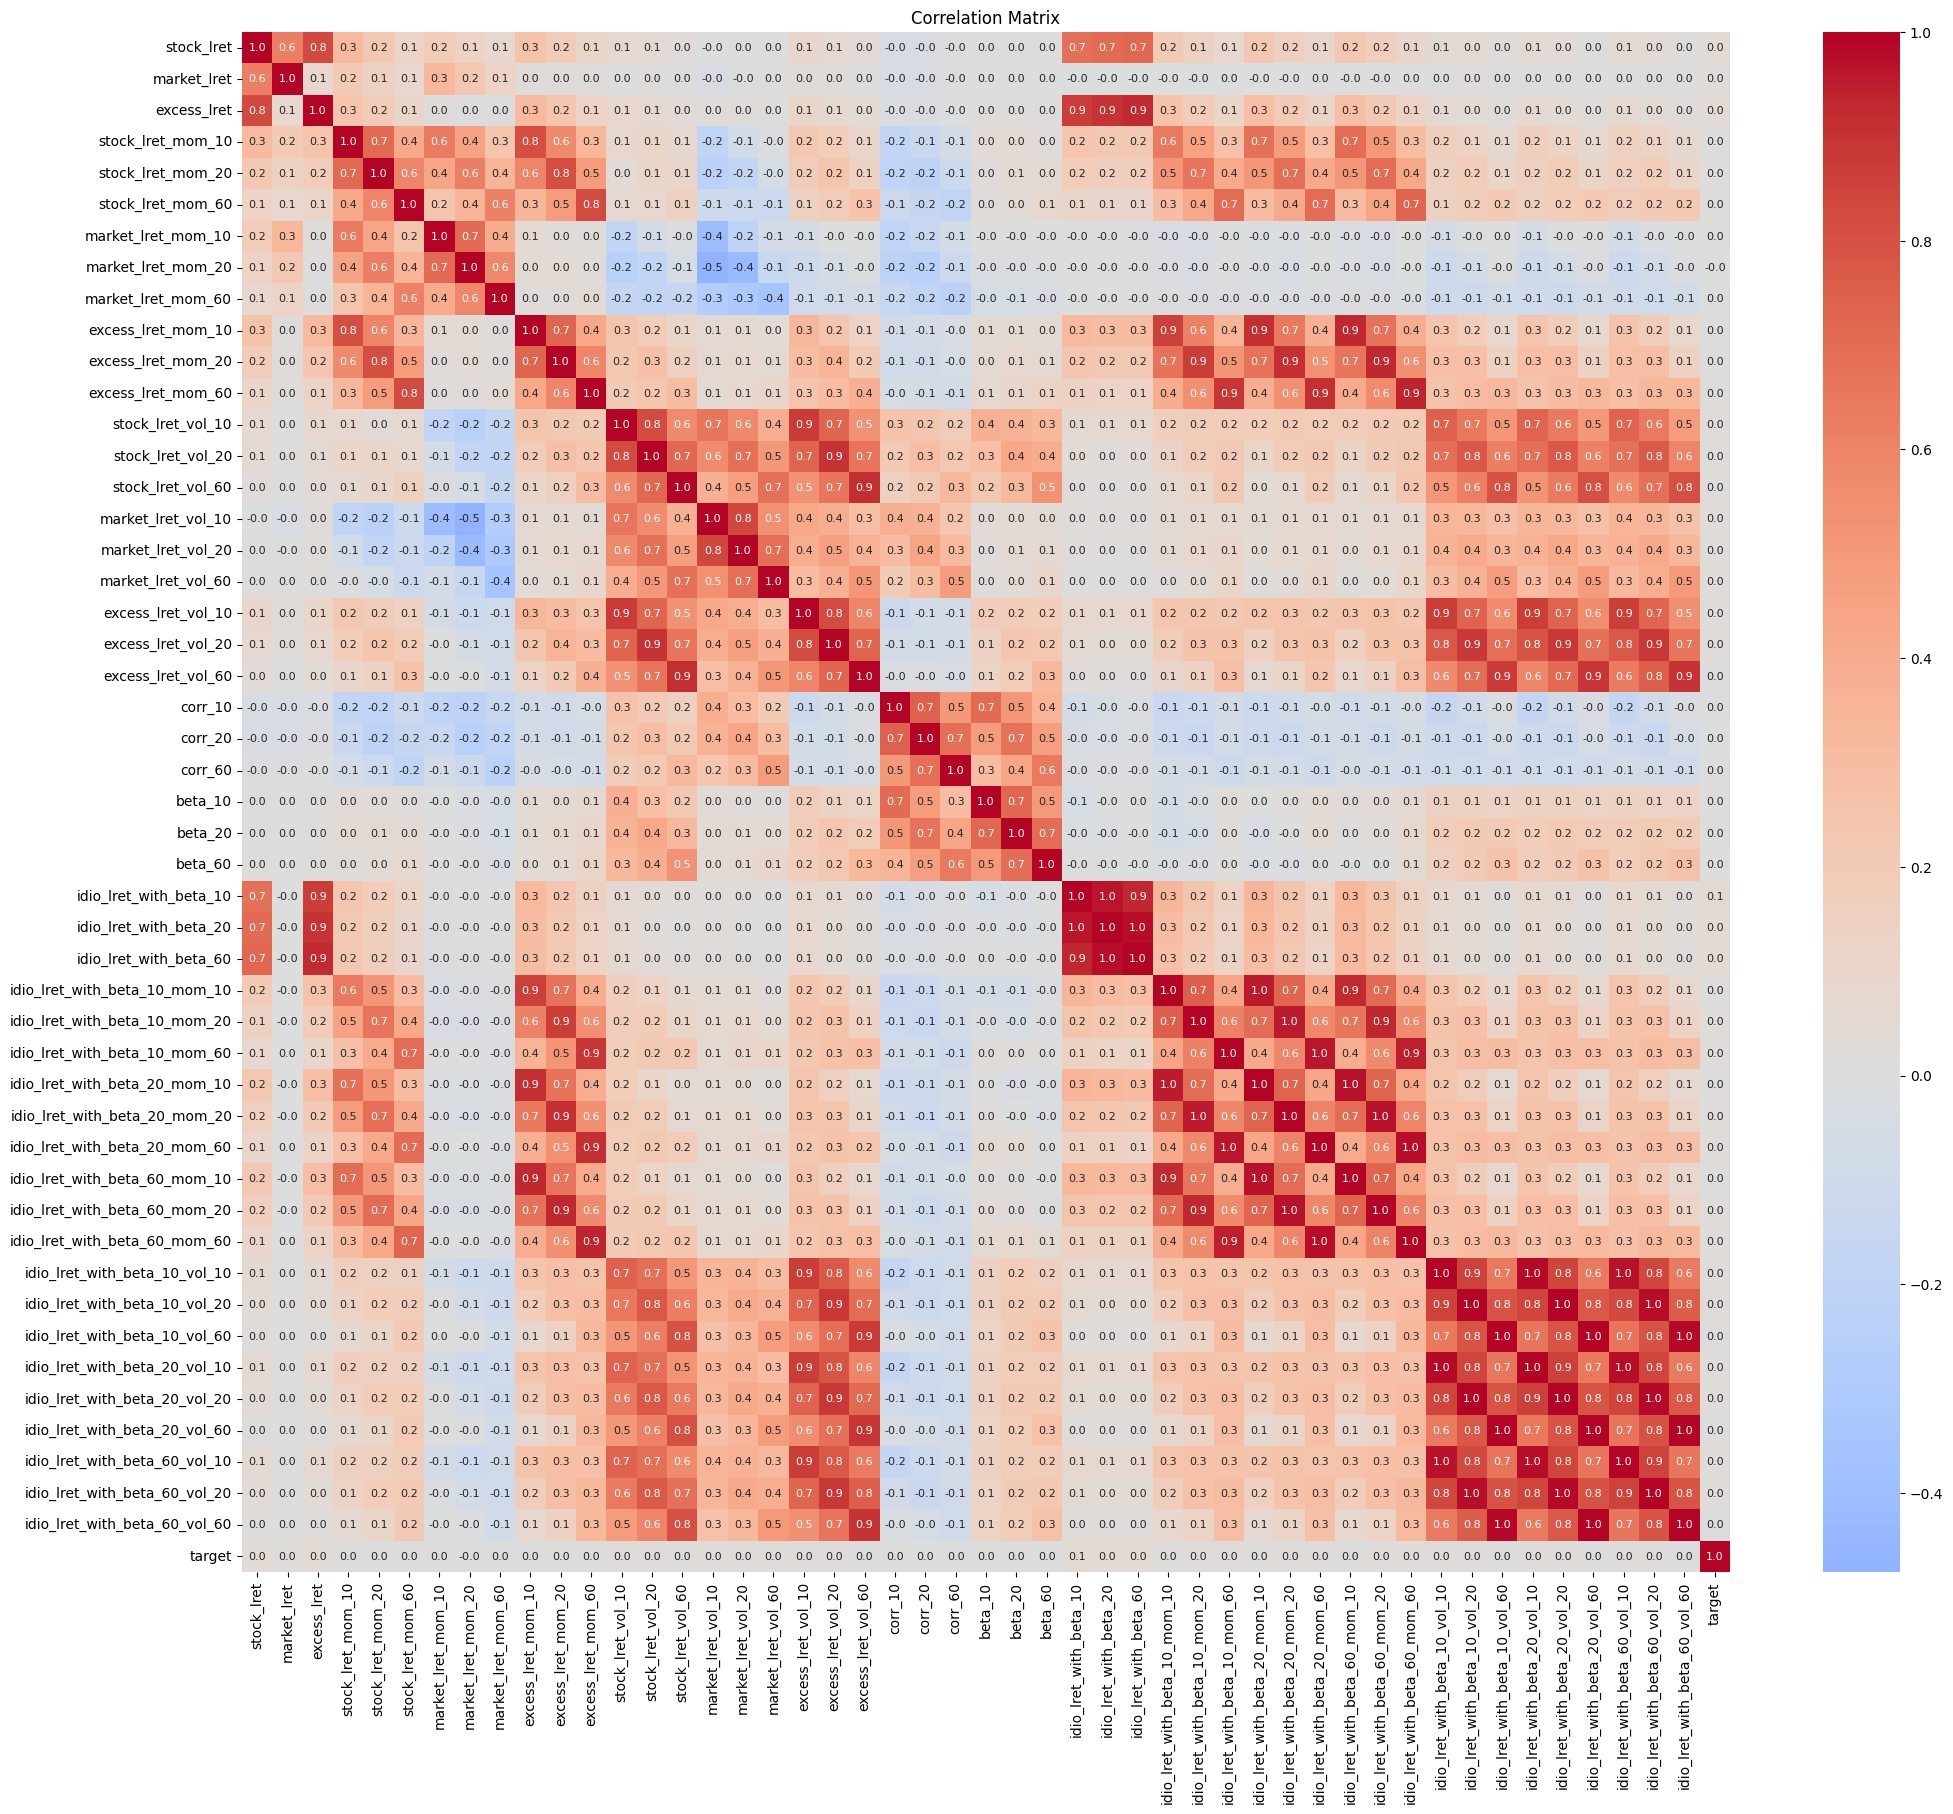

In [17]:
df_num = df_final.select_dtypes(include=["float64", "int64"])

corr = df_num.corr()

plt.figure(figsize=(24, 20))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,      
    fmt=".1f",       
    annot_kws={"size": 8}
)
plt.title("Correlation Matrix")
plt.show()

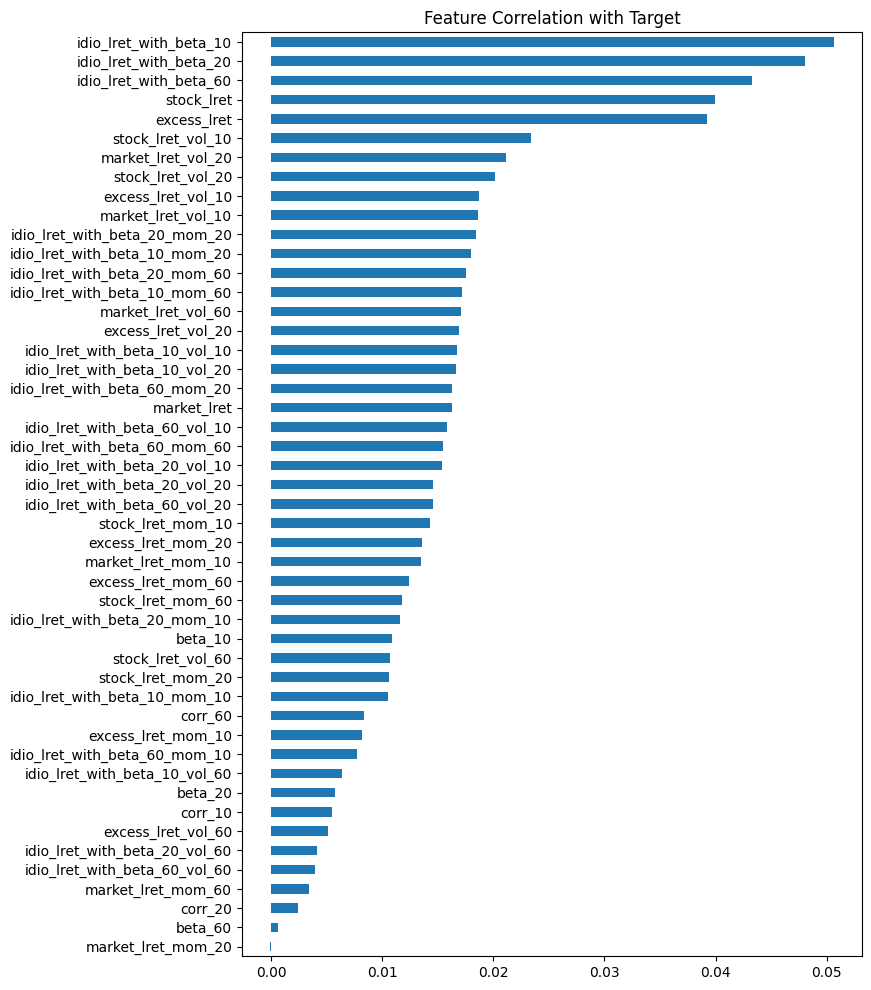

In [18]:
corr_target = df_num.corr()["target"].sort_values()

plt.figure(figsize=(8, 12))
corr_target.drop("target").plot(kind="barh")
plt.title("Feature Correlation with Target")
plt.show()

In [19]:
corr_target.sort_values(ascending=False)

target                           1.000000
idio_lret_with_beta_10           0.050638
idio_lret_with_beta_20           0.048076
idio_lret_with_beta_60           0.043314
stock_lret                       0.039906
excess_lret                      0.039265
stock_lret_vol_10                0.023417
market_lret_vol_20               0.021132
stock_lret_vol_20                0.020181
excess_lret_vol_10               0.018729
market_lret_vol_10               0.018659
idio_lret_with_beta_20_mom_20    0.018420
idio_lret_with_beta_10_mom_20    0.018029
idio_lret_with_beta_20_mom_60    0.017557
idio_lret_with_beta_10_mom_60    0.017136
market_lret_vol_60               0.017082
excess_lret_vol_20               0.016864
idio_lret_with_beta_10_vol_10    0.016763
idio_lret_with_beta_10_vol_20    0.016646
idio_lret_with_beta_60_mom_20    0.016247
market_lret                      0.016243
idio_lret_with_beta_60_vol_10    0.015813
idio_lret_with_beta_60_mom_60    0.015422
idio_lret_with_beta_20_vol_10    0

# Train/Val/Test

In [20]:
def split_time_series(df,
                      train_start='2018-01-01',
                      train_end='2023-01-01',
                      val_end='2024-01-01',
                      test_end=None,
                      time_col='time'):
    
    df = df.copy()

    train_df = df[
        (df[time_col] >= train_start) &
        (df[time_col] < train_end)
    ]

    val_df = df[
        (df[time_col] >= train_end) &
        (df[time_col] < val_end)
    ]

    if test_end is not None:
        test_df = df[
            (df[time_col] >= val_end) &
            (df[time_col] < test_end)
        ]
    else:
        test_df = df[df[time_col] >= val_end]

    return train_df, val_df, test_df

In [21]:
train_df, val_df, test_df = split_time_series(df_final)
train_df.shape, val_df.shape, test_df.shape

((29881, 52), (5976, 52), (11952, 52))

In [22]:
print(train_df['time'].min(), train_df['time'].max())
print(val_df['time'].min(), val_df['time'].max())
print(test_df['time'].min(), test_df['time'].max())

2018-01-02 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2025-12-30 00:00:00


In [23]:
print(train_df["symbol"].nunique())
print(val_df["symbol"].nunique())
print(test_df["symbol"].nunique())

24
24
24


In [24]:
set(test_df.symbol.unique()) - set(train_df.symbol.unique())

set()

In [25]:
symbols_in_train = train_df['symbol'].unique()

test_df = test_df[test_df['symbol'].isin(symbols_in_train)]

test_df['symbol'].nunique(), test_df.shape

(24, (11952, 52))

# Create sequences

In [26]:
def create_sequences(df, window=20, feature_col='log_return', target_col='target'):
    X, y, meta = [], [], [] 
    
    for symbol, sub_df in df.groupby('symbol'):
        sub_df = sub_df.sort_values('time').reset_index(drop=True)

        values_x = sub_df[feature_col].values
        values_y = sub_df[target_col].values
        
        for i in range(len(sub_df) - window):
            X.append(values_x[i : i + window])
            y.append(values_y[i + window - 1])
            meta.append({
                'symbol': symbol,
                'time': sub_df['target_time'].iloc[i + window - 1]
            })
    
    X = np.array(X).reshape(-1, window, 1)
    y = np.array(y)
    meta_df = pd.DataFrame(meta)
    
    return X, y, meta_df

In [27]:
X_train, y_train, meta_train = create_sequences(train_df)
X_train.shape, y_train.shape, meta_train.shape

KeyError: 'log_return'

In [ ]:
X_val, y_val, meta_val = create_sequences(val_df)
X_val.shape, y_val.shape, meta_val.shape

KeyError: 'log_return'

In [ ]:
X_test, y_test, meta_test = create_sequences(test_df)
X_test.shape, y_test.shape, meta_test.shape

KeyError: 'log_return'

In [ ]:
34511+20*29, 6641+20*29, 13862+20*29

(35091, 7221, 14442)

# Building LSTM